In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## FIFA Dataset Description

This dataset contains detailed information about football players, including their attributes, contract data, and positions. Below is a breakdown of the main features:

### Feature Table with Descriptions

**Original Features**

| Column Name          | Description |
|:---------------------|:------------|
| LongName             | Player’s full name |
| Nationality          | Player’s nationality |
| Positions            | Player’s positions |
| Name                 | Player’s name |
| Age                  | Player’s age |
| Overall Rating       | Player’s overall rating |
| Potential            | Player’s potential rating |
| ID                   | Player’s unique identifier |
| Weight               | Player’s weight |
| foot                 | Player’s dominant foot |
| Best Overall         | Player’s best overall rating |
| Best Position        | Player’s best position |
| Growth               | Player’s growth potential |
| Value                | Player’s market value |
| Wage                 | Player’s wage |
| Release Clause       | Player’s release clause amount |
| ... (and so on)      | ... (descriptions for other features) |

**Encoded Positions**

| Column Name | Description |
|:------------|:------------|
| CM          | Central Midfielder |
| ST          | Striker |
| RB          | Right Back |
| GK          | Goalkeeper |
| CB          | Center Back |
| RWB         | Right Wing Back |
| LB          | Left Back |
| RM          | Right Midfielder |
| LM          | Left Midfielder |
| LW          | Left Winger |
| CDM         | Defensive Midfielder |
| CAM         | Attacking Midfielder |
| LWB         | Left Wing Back |
| CF          | Center Forward |
| RW          | Right Winger |

**Additional Features**

| Column Name | Description |
|:------------|:------------|
| Team        | Player’s team |
| Start Year  | Player’s contract start year |
| End Year    | Player’s contract end year |
| Height      | Player’s height |
| Date        | Date the player joined the team |
| Year        | Player’s contract year |
| Month       | Player’s contract month |
| Day         | Player’s contract day |
| Hits        | Unknown attribute (requires further clarification) |


# Reading and cleaning both datasets

In [7]:
df_soccer = pd.read_excel('FIFA_Complete_DATASET.xlsx', sheet_name='Fifa')
df_airplanes = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

## Cleaning Fifa Dataset

In [9]:
df_soccer.head()

,LongName,Nationality,Positions,Name,Age,Overall Rating,Potential,ID,Weight,foot,...,Physicality,Hits,Team,Start Year,End Year,Height,Date,Year,Month,Day
0,Lionel Messi,Argentina,RW ST CF,L. Messi,33,93,93,158023,72.121128,Left,...,65,372,FC Barcelona,2004.0,2021.0,159.40,2004-07-01,2004,7,1
1,C. Ronaldo dos Santos Aveiro,Portugal,ST LW,Cristiano Ronaldo,35,92,92,20801,83.007336,Right,...,77,344,Juventus,2018.0,2022.0,184.88,2018-07-10,2018,7,10
2,Jan Oblak,Slovenia,GK,J. Oblak,27,91,93,200389,87.089664,Right,...,90,86,Atlético Madrid,2014.0,2023.0,184.88,2014-07-16,2014,7,16
3,Kevin De Bruyne,Belgium,CAM CM,K. De Bruyne,29,91,91,192985,69.853168,Right,...,78,163,Manchester City,2015.0,2023.0,163.40,2015-08-30,2015,8,30
4,Neymar da Silva Santos Jr.,Brazil,LW CAM,Neymar Jr,28,91,91,190871,68.038800,Right,...,59,273,Germain,2017.0,2022.0,161.40,2017-08-03,2017,8,3


In [10]:
df_soccer.shape

(18852, 79)

In [11]:
df_soccer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18852 entries, 0 to 18851
Data columns (total 79 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   LongName                  18852 non-null  object        
 1   Nationality               18852 non-null  object        
 2   Positions                 18852 non-null  object        
 3   Name                      18852 non-null  object        
 4   Age                       18852 non-null  int64         
 5   Overall Rating            18852 non-null  int64         
 6   Potential                 18852 non-null  int64         
 7   ID                        18852 non-null  int64         
 8   Weight                    18852 non-null  float64       
 9   foot                      18852 non-null  object        
 10  Best Overall              18852 non-null  int64         
 11  Best Position             18852 non-null  object        
 12  Growth            

In [12]:
features_for_clustering = [
    'Finishing',
    'Short Passing',
    'Standing Tackle',
    'Sprint Speed',
    'Strength',
    'Dribbling',
    'Crossing',
    'Interceptions',
    'Vision',
    'GK Reflexes'
]

In [13]:
df_soccer_clustering = df_soccer[features_for_clustering]

In [16]:
df_soccer_clustering.head()

,Finishing,Short Passing,Standing Tackle,Sprint Speed,Strength,Dribbling,Crossing,Interceptions,Vision,GK Reflexes
0,95,91,35,80,69,96,85,40,95,8
1,95,82,32,91,78,88,84,29,82,11
2,11,43,12,60,78,12,13,19,65,90
3,82,94,65,76,74,88,94,66,94,13
4,87,87,30,89,50,95,85,36,90,11


### Univariate and Multivariate Analysis

In [47]:
import math

def plot_feature_distributions(df: pd.DataFrame, features:list, flag:str='hist'):
    n_features = len(features)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    
    for i, feature in enumerate(features):
        if flag == 'hist':
            sns.histplot(df[feature], kde=True, bins=30, ax=axes[i])
        else:
            sns.boxplot(x=df[feature], ax=axes[i])
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [48]:
def remove_outliers(df: pd.DataFrame, columns: list = None, threshold: float = 1.5) -> pd.DataFrame:
    
    mask = pd.Series(True, index=df.index)

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - threshold * IQR
        upper = Q3 + threshold * IQR
        mask &= df[col].between(lower, upper)

    return df[mask].reset_index(drop=True)

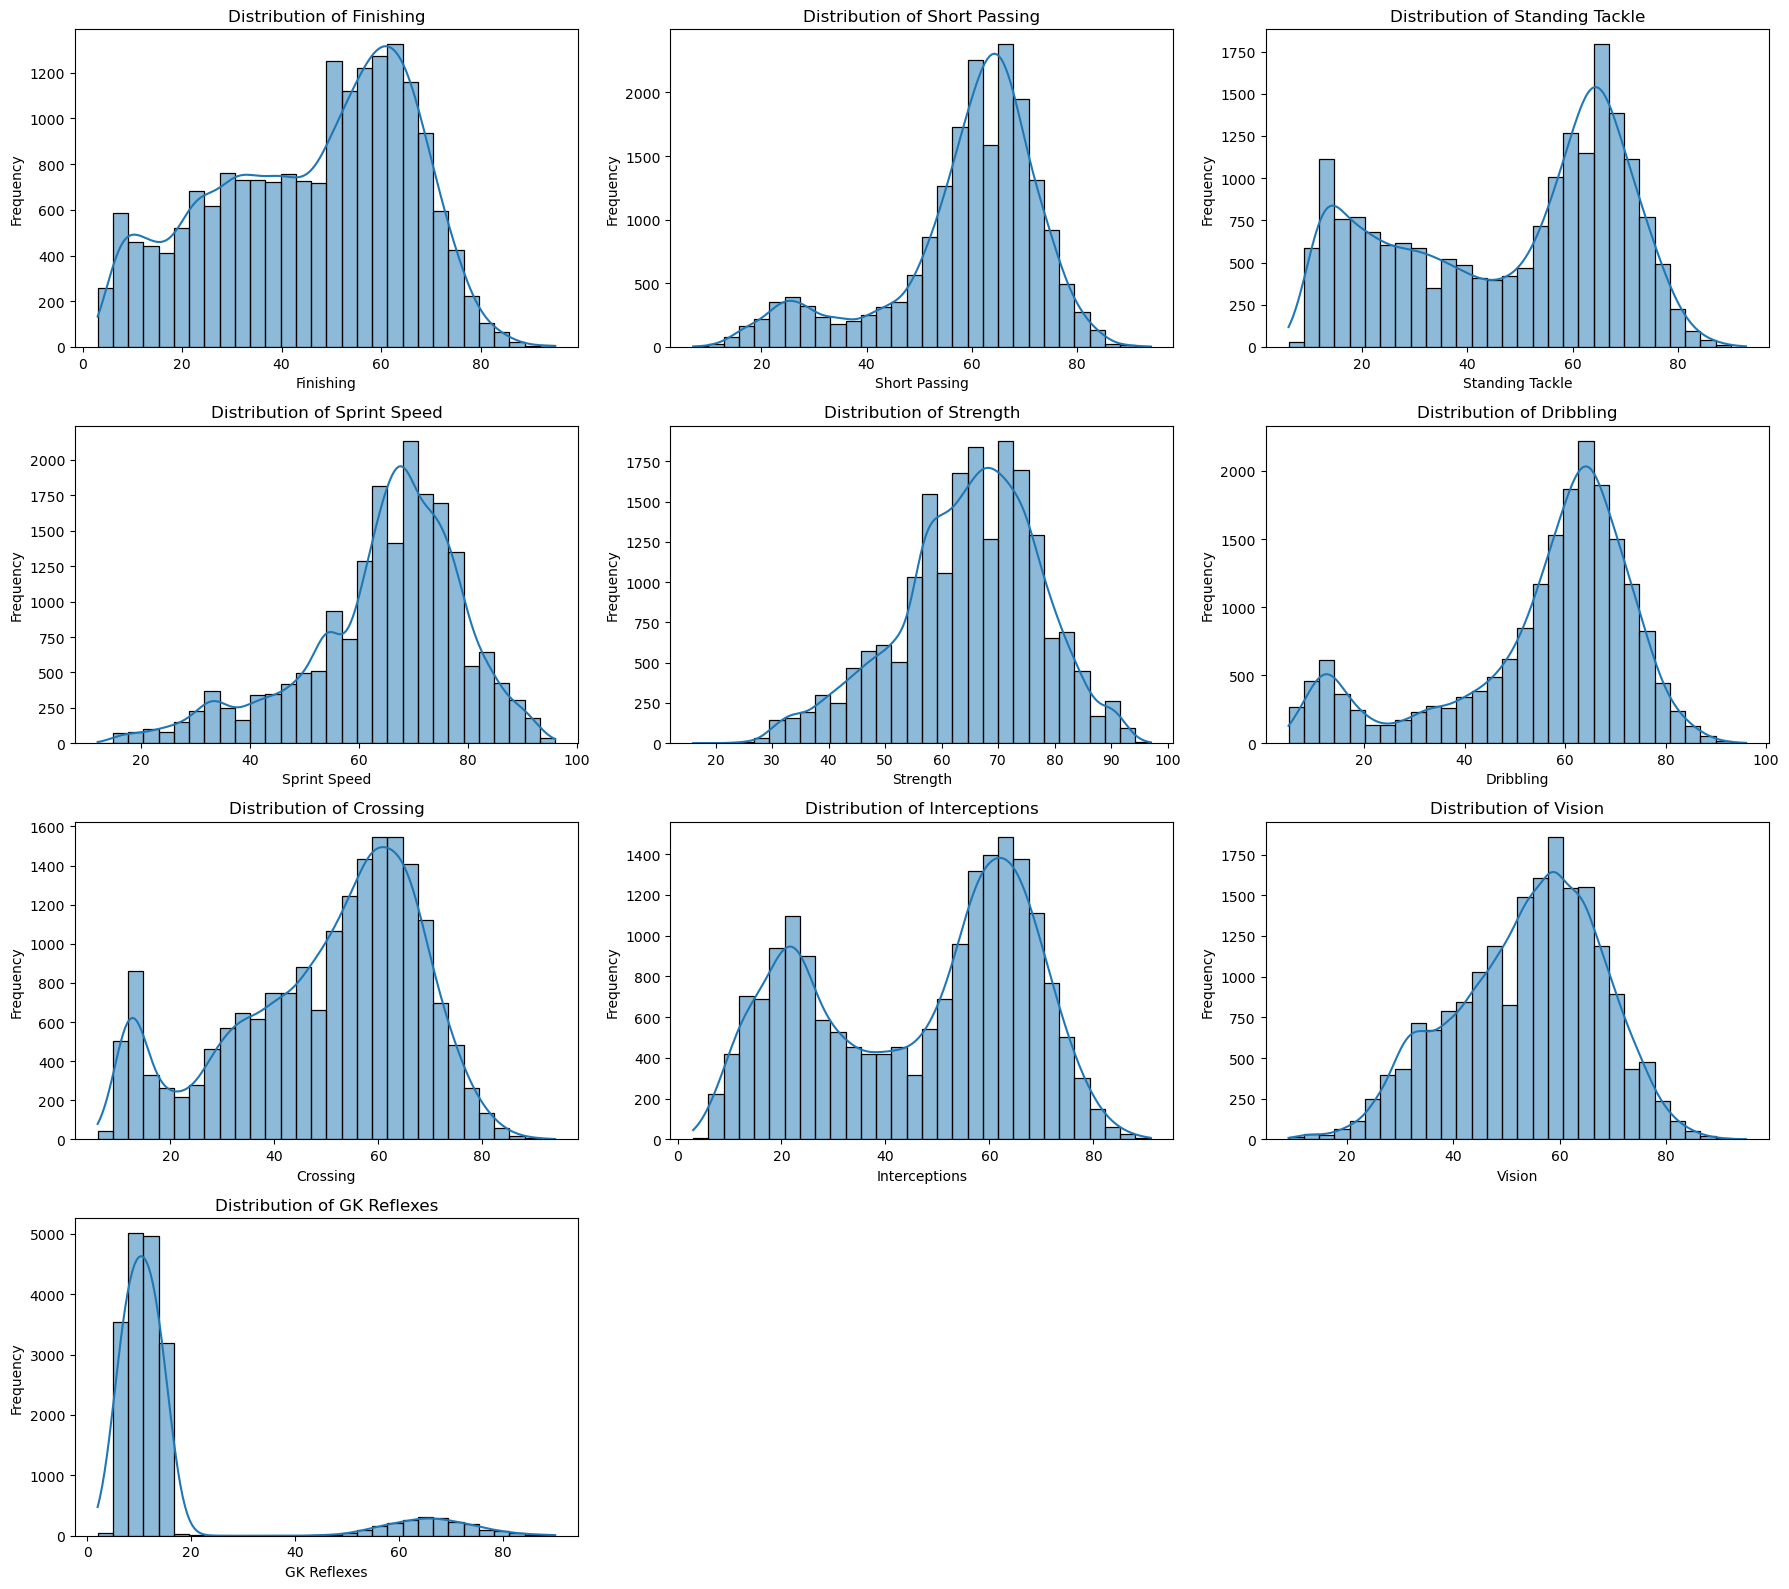

In [36]:
plot_feature_distributions(df_soccer_clustering, features_for_clustering)

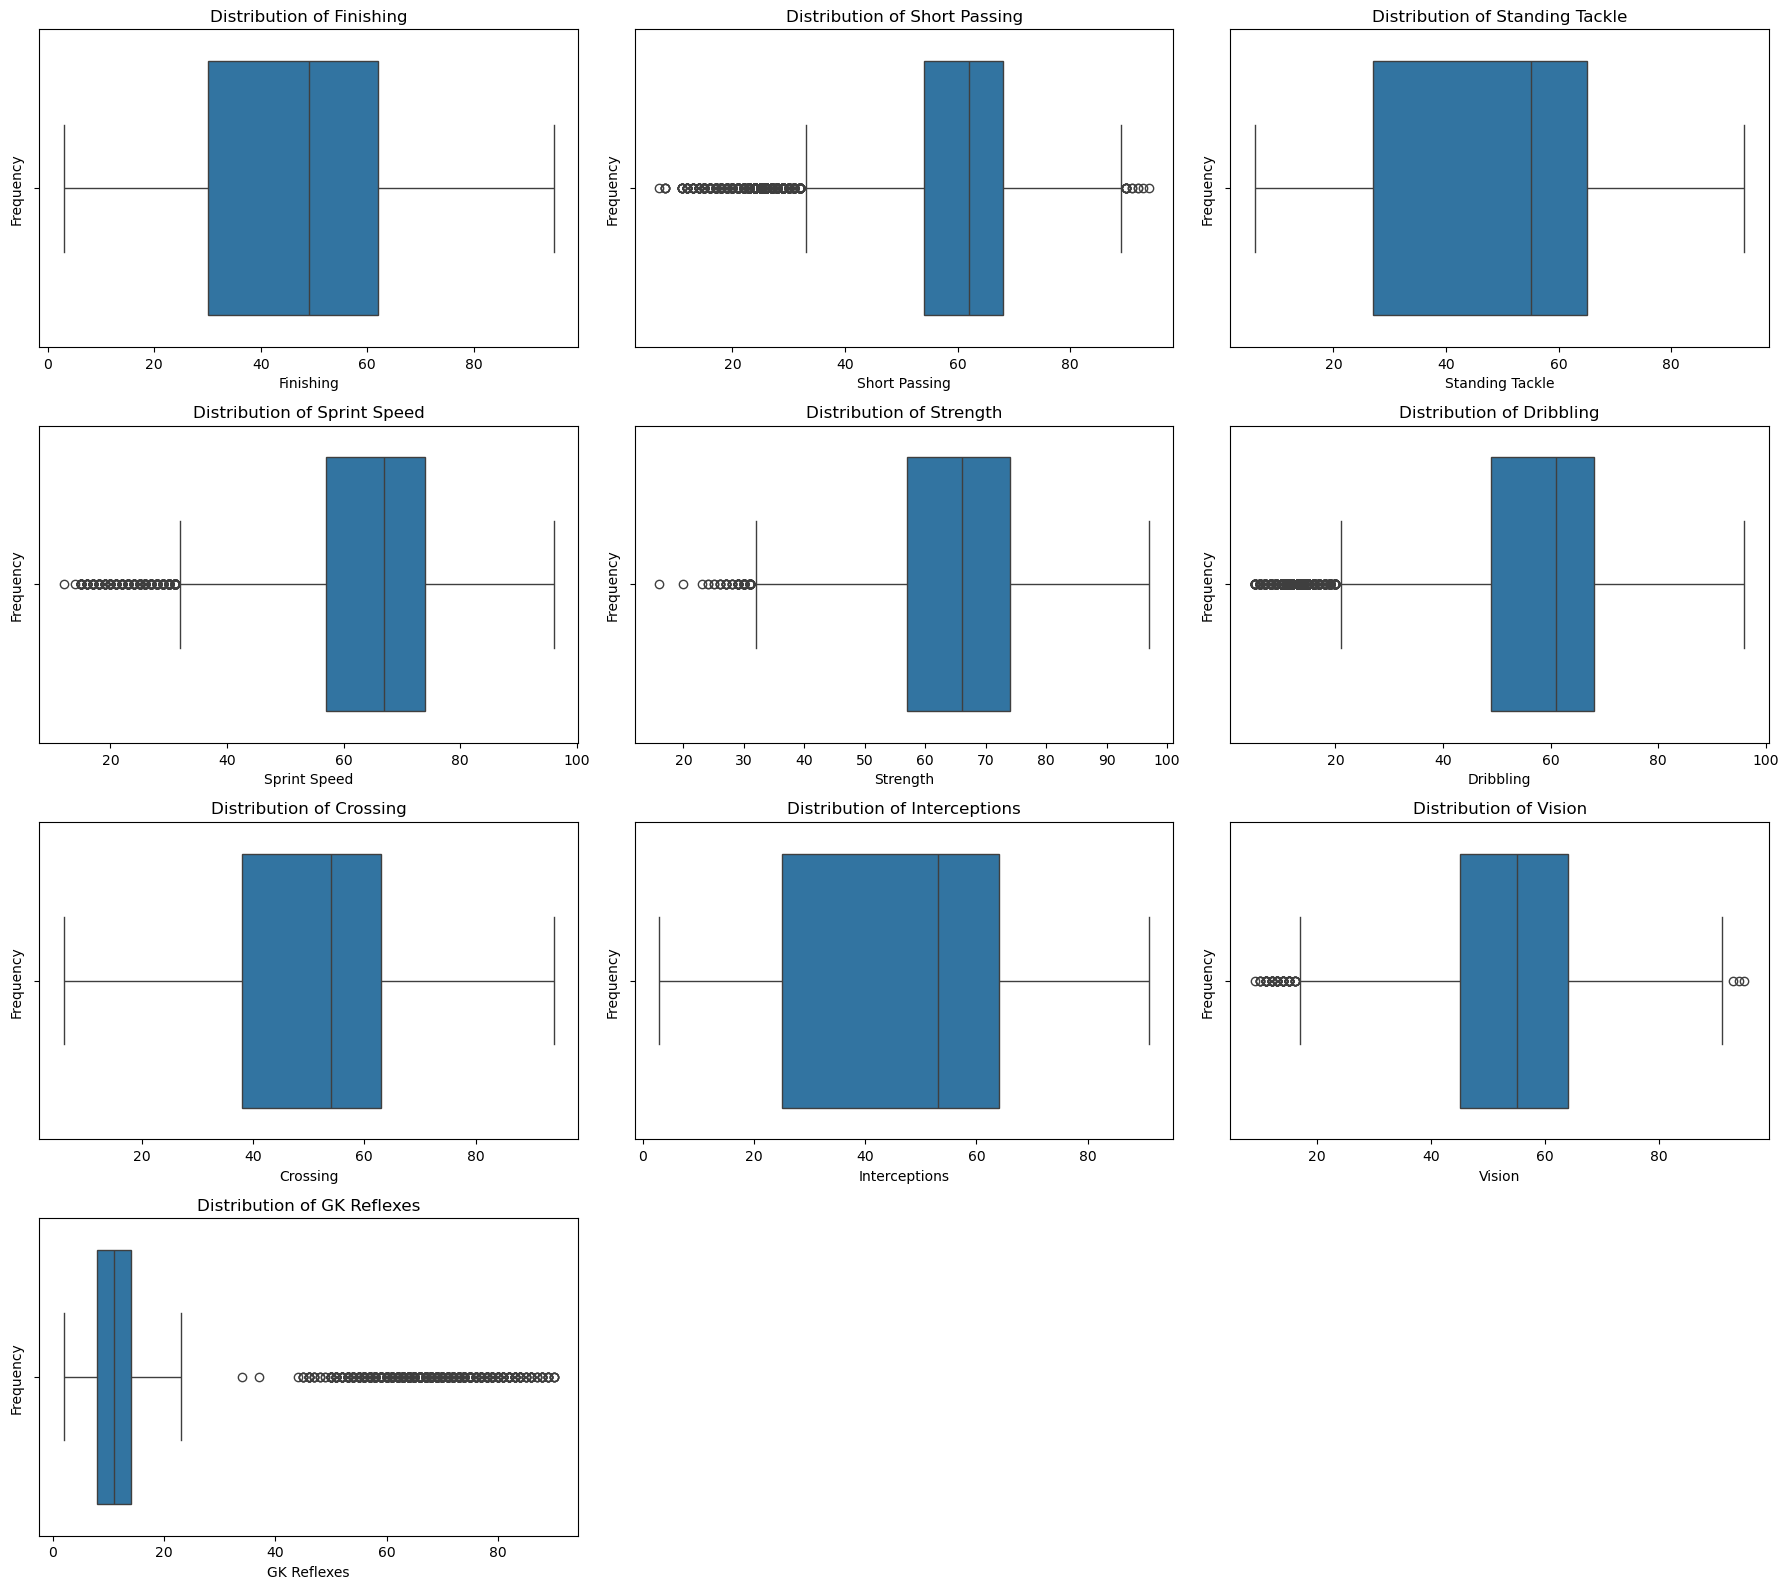

In [37]:
plot_feature_distributions(df_soccer_clustering, features_for_clustering, flag='box')

In [70]:
from sklearn.preprocessing import RobustScaler, FunctionTransformer, PowerTransformer
from sklearn.pipeline import Pipeline

# 1. Define the log transformer to handle skewness
log_transformer = FunctionTransformer(np.log1p)

# 2. Build the preprocessing pipeline
preprocessor = Pipeline(steps=[
    ('power', PowerTransformer(method='yeo-johnson')),    # Fixes skewness
    ('scale', RobustScaler())    # Fixes outliers & scaling
])

X_processed = preprocessor.fit_transform(df_soccer_clustering)

In [71]:
df_processed = pd.DataFrame(X_processed, columns=features_for_clustering)

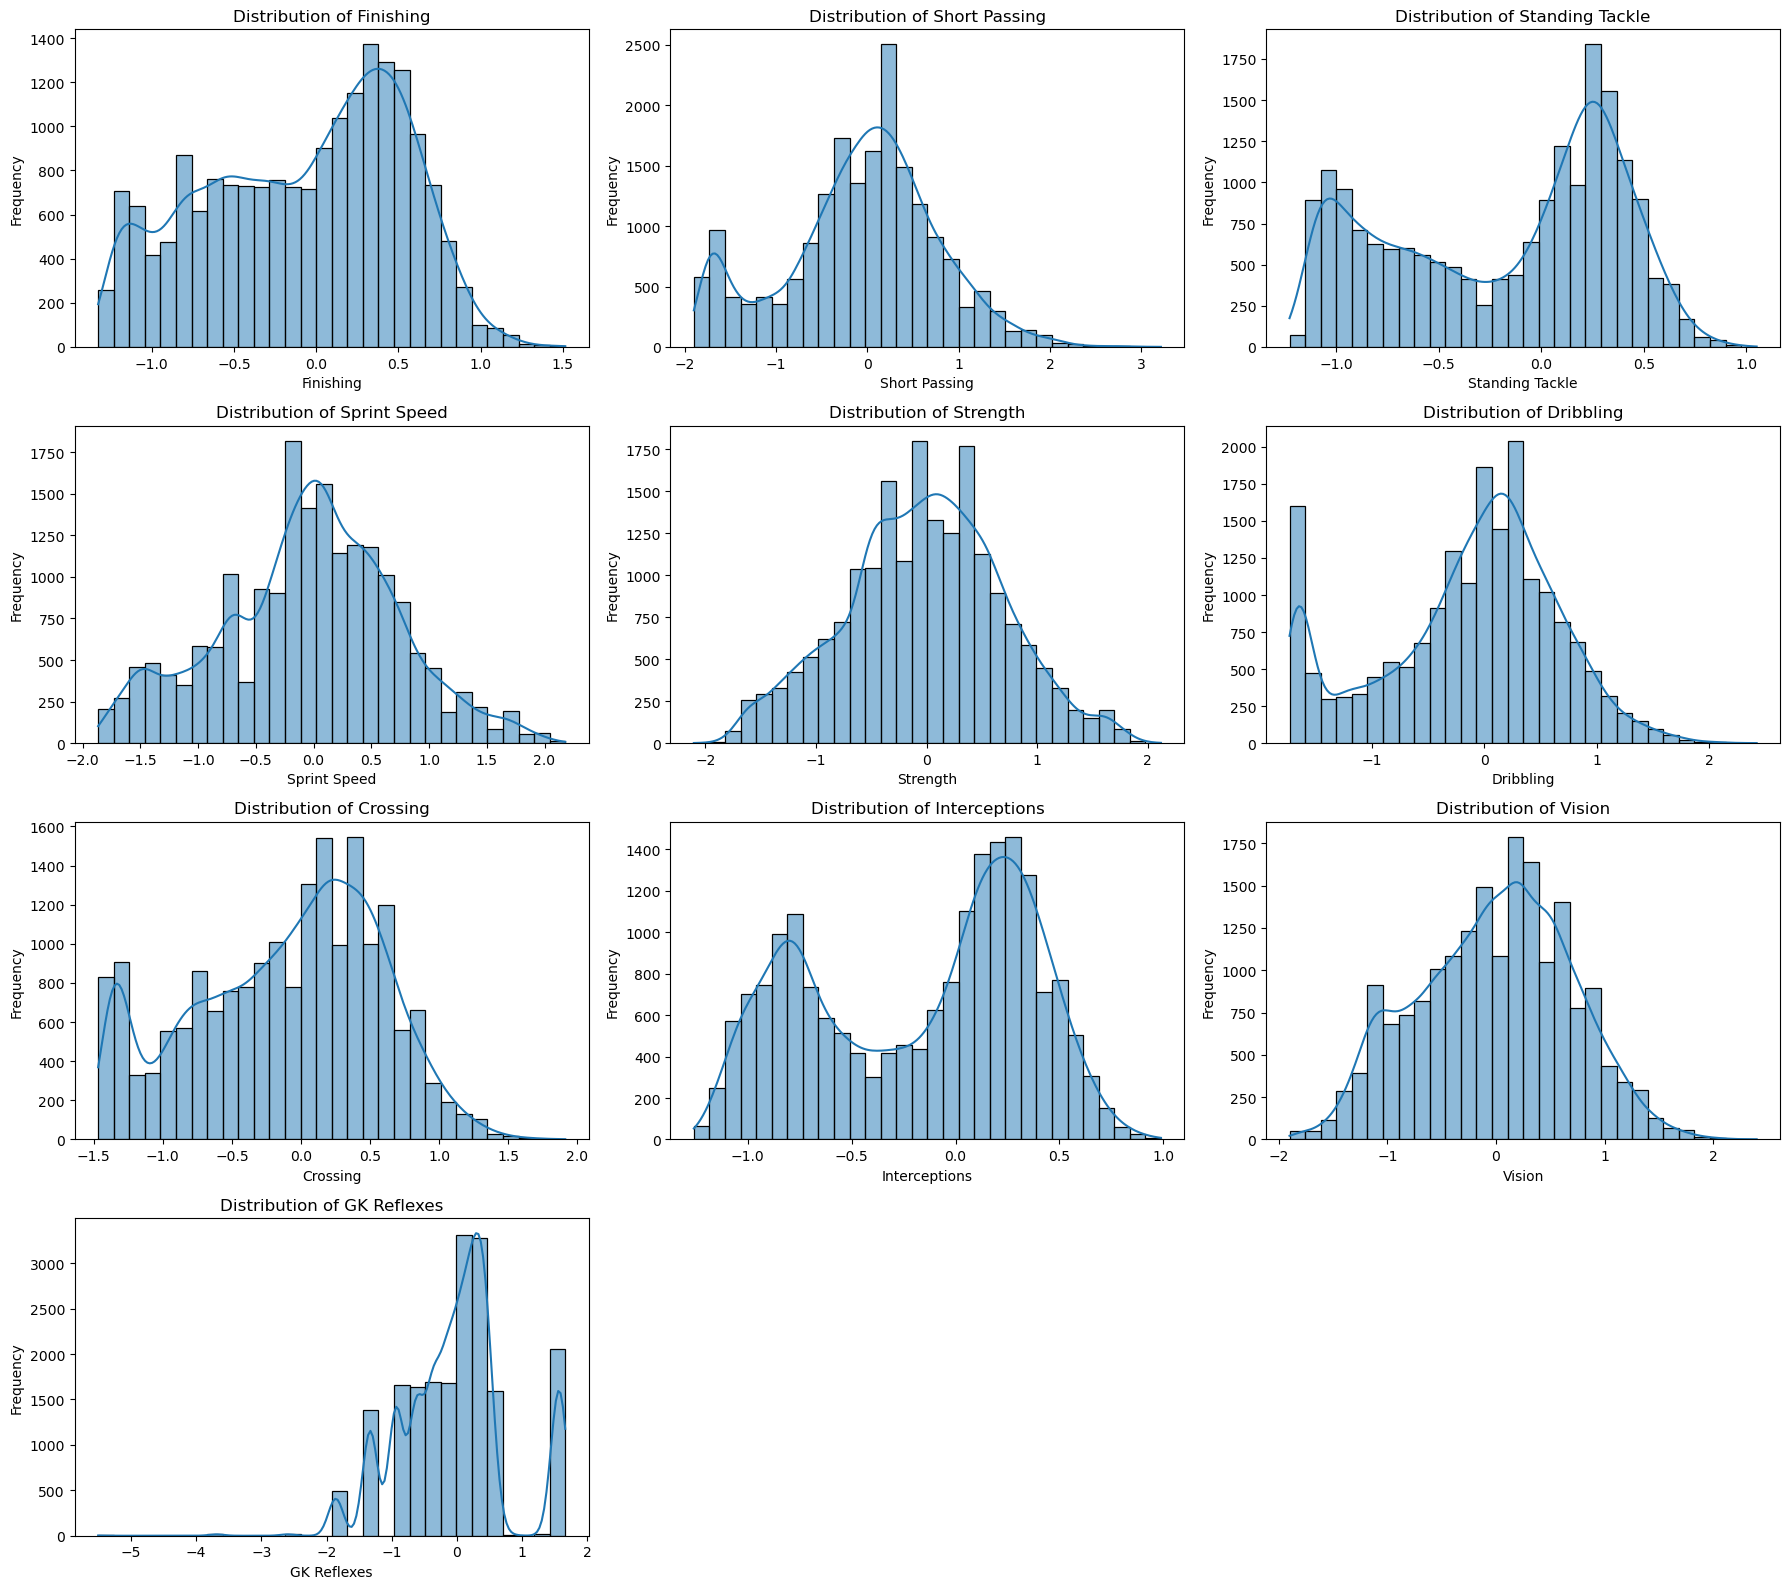

In [72]:
plot_feature_distributions(df_processed, df_processed.columns)

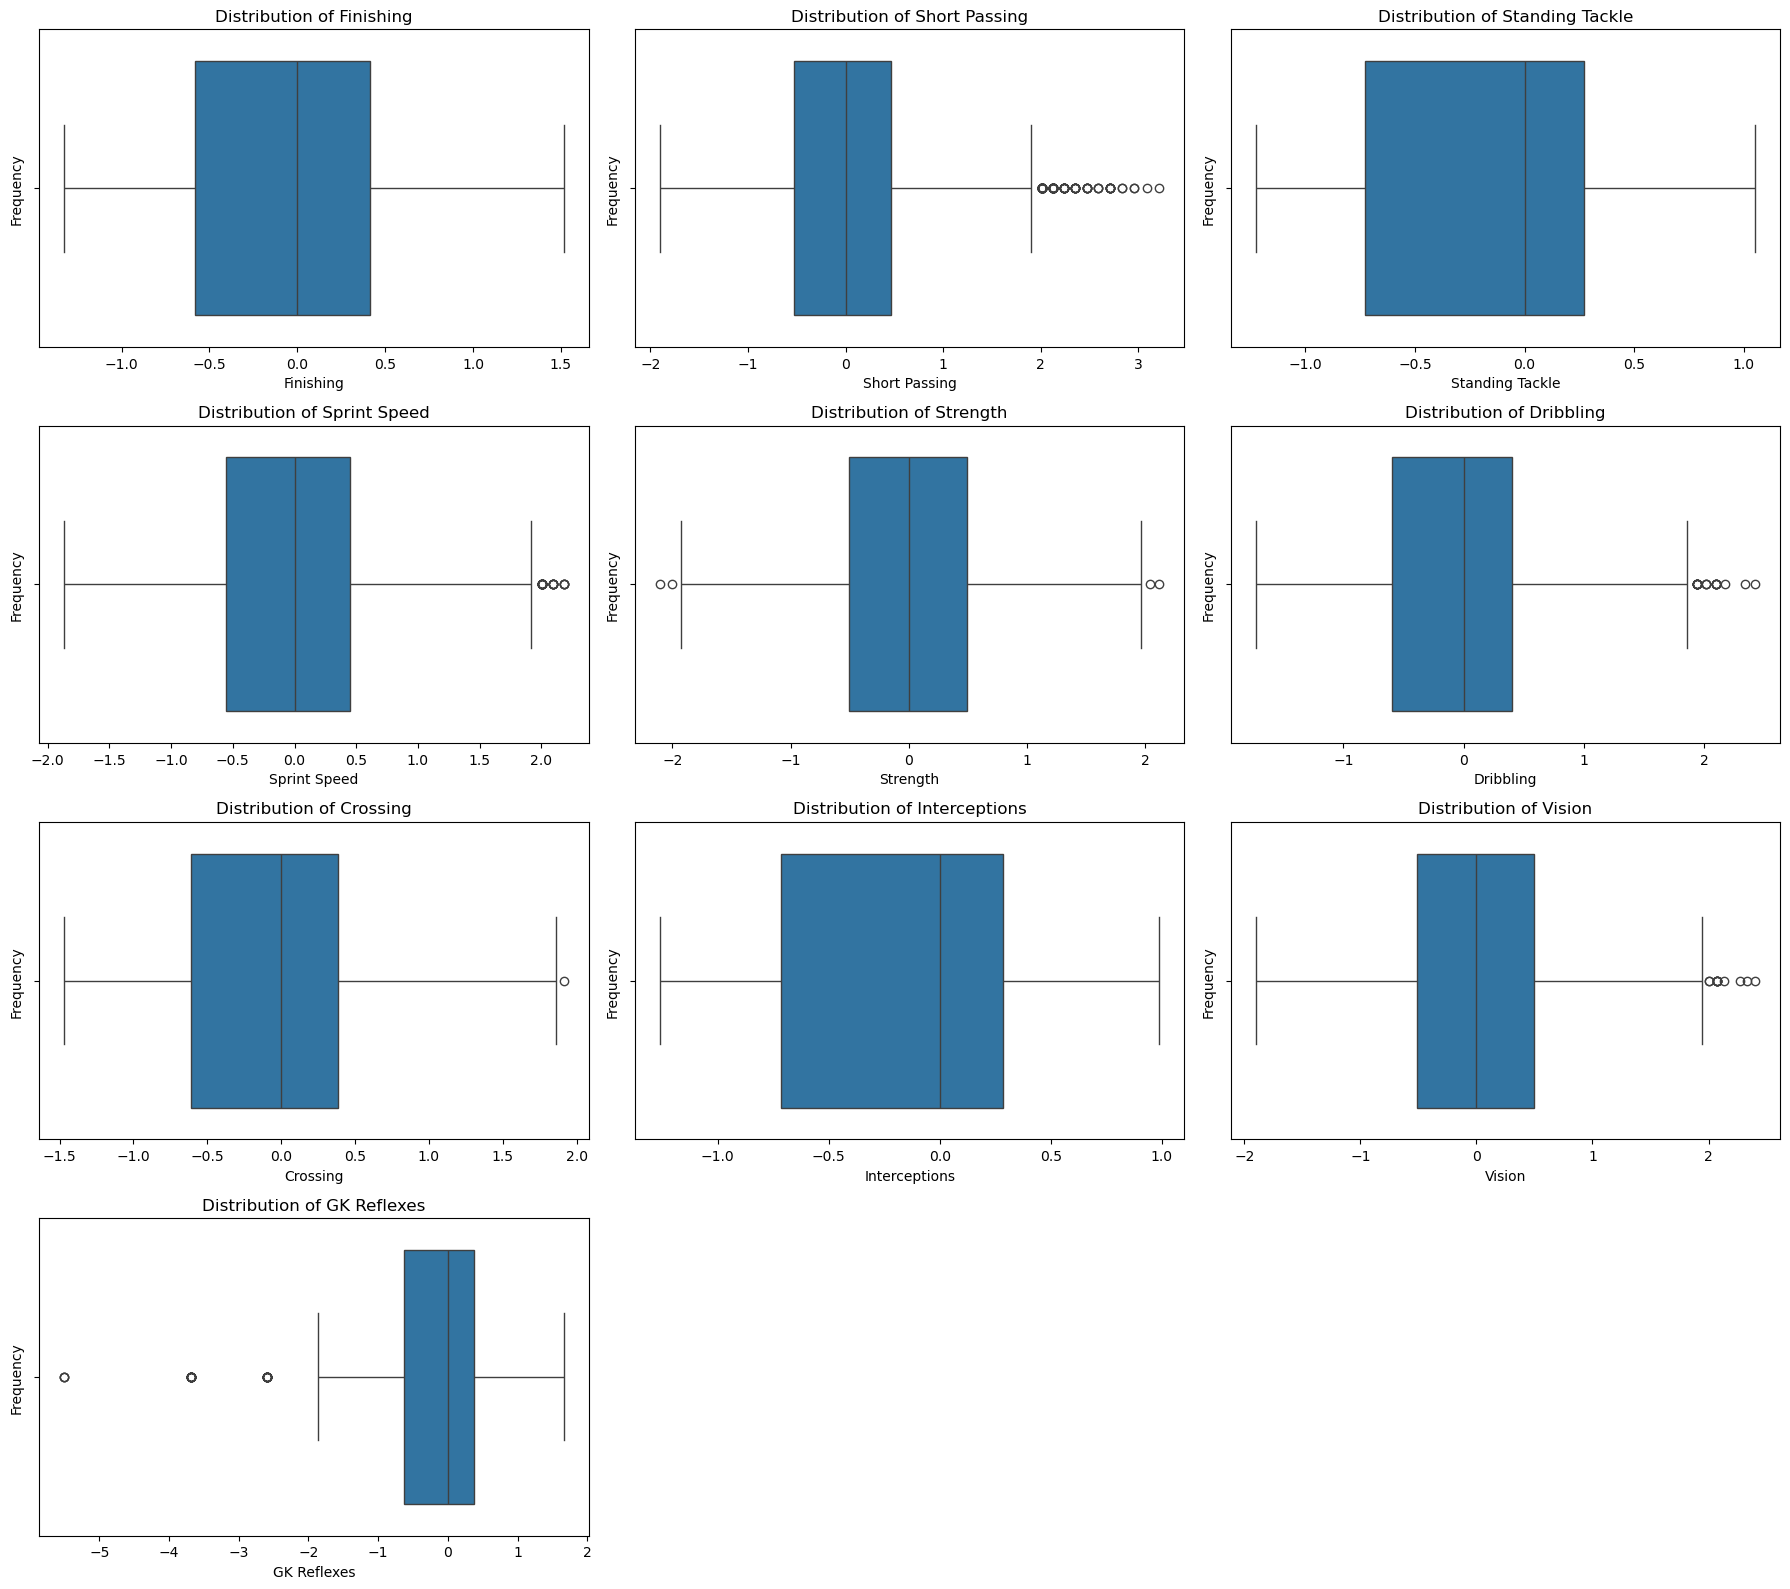

In [73]:
plot_feature_distributions(df_processed, df_processed.columns, flag='box')

#### Proving Deleting outliers

In [74]:
df_processed_without_outliers = remove_outliers(df_processed, columns=df_processed.columns)

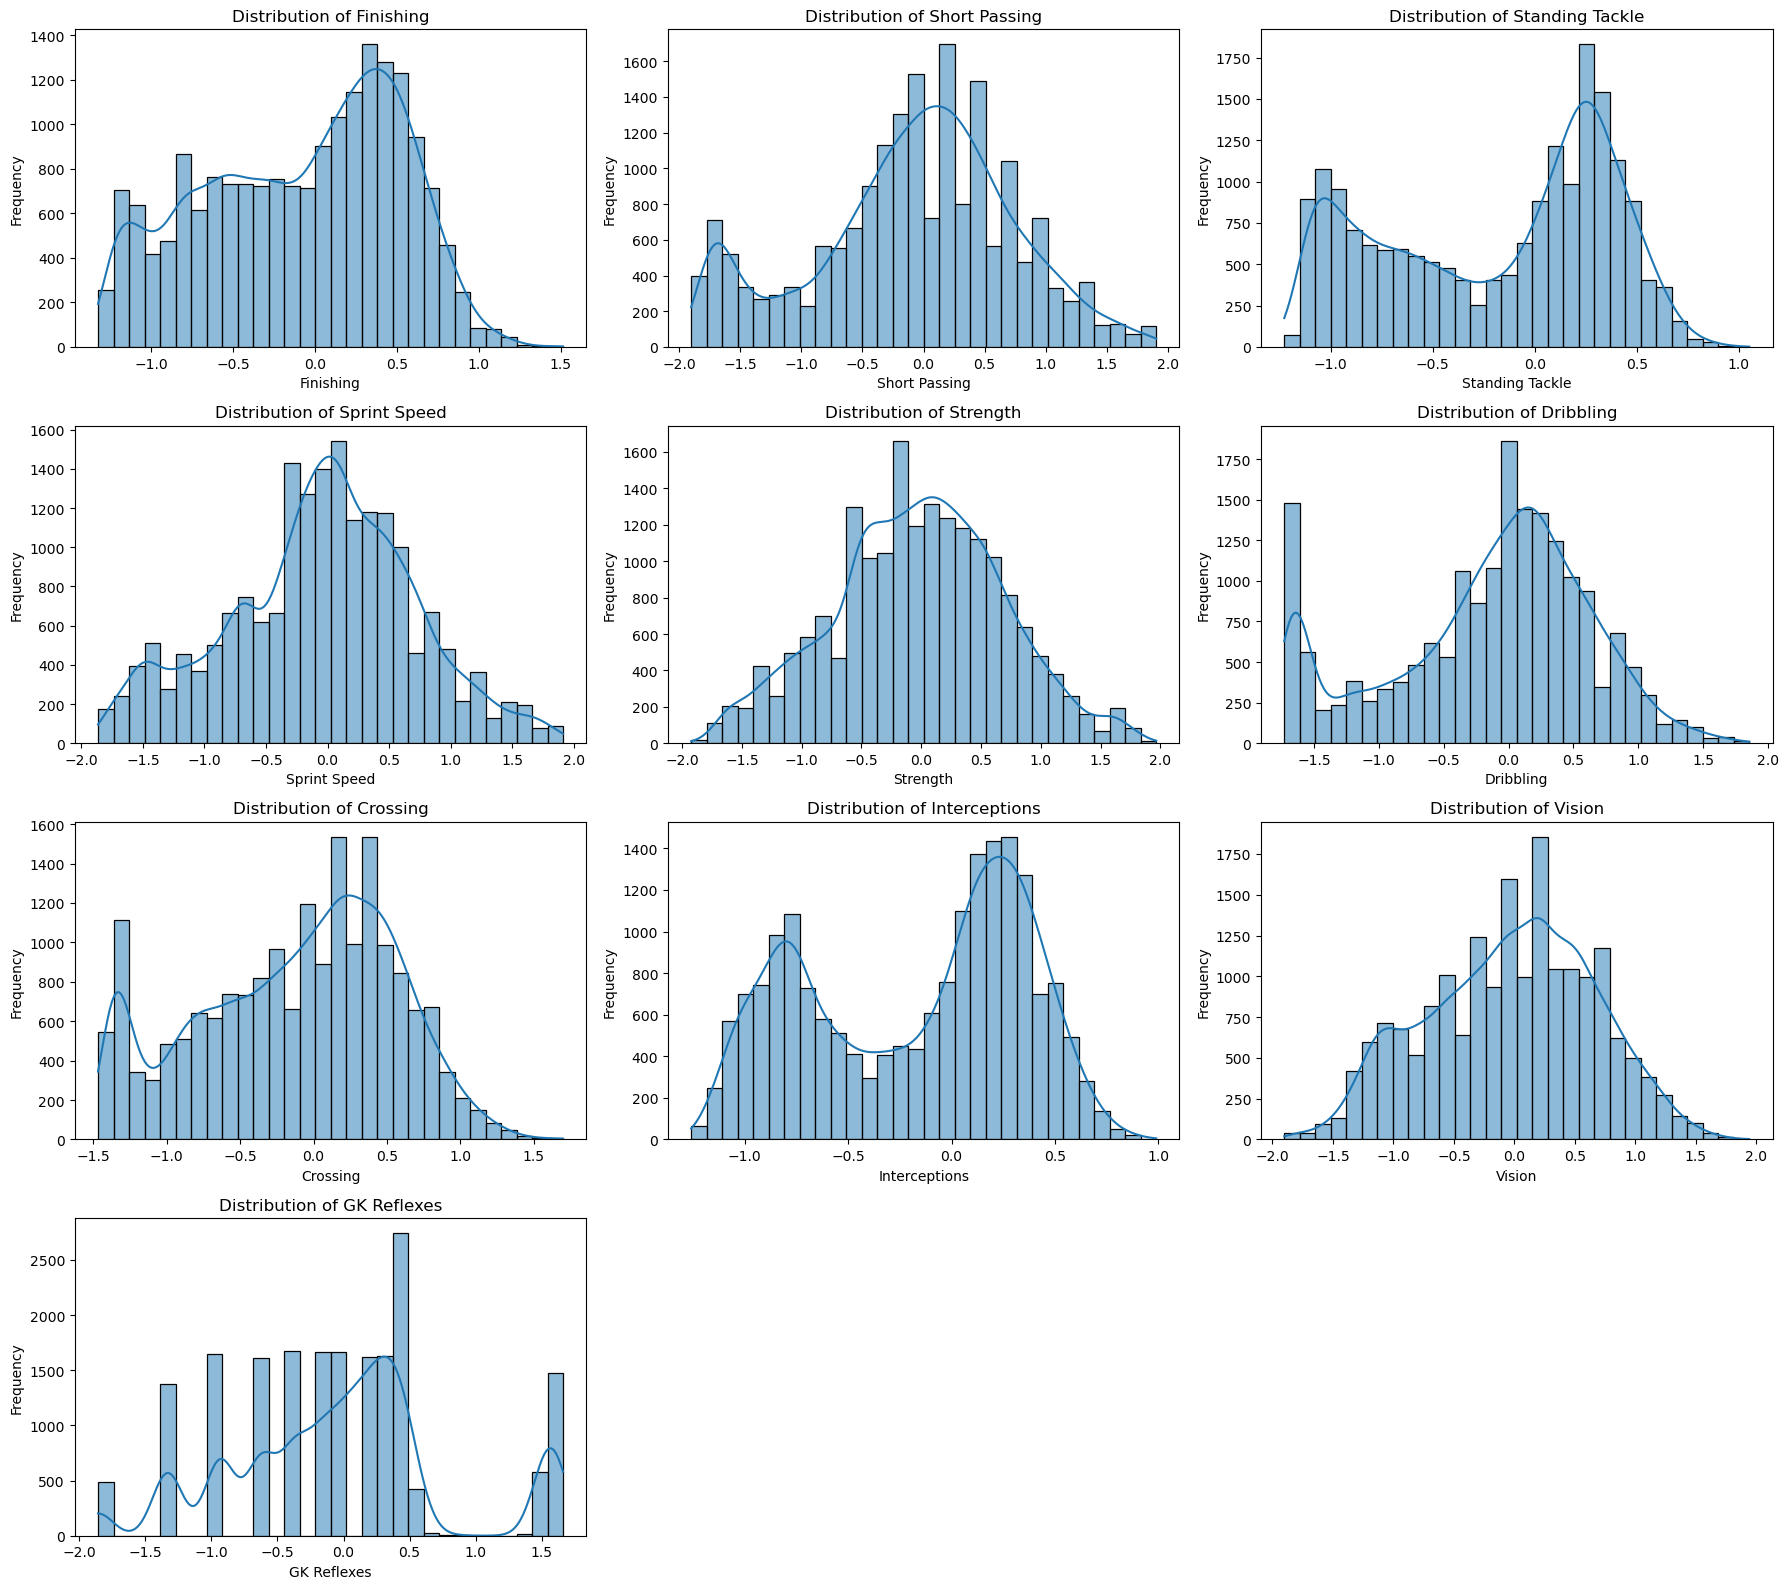

In [75]:
plot_feature_distributions(df_processed_without_outliers, features_for_clustering)

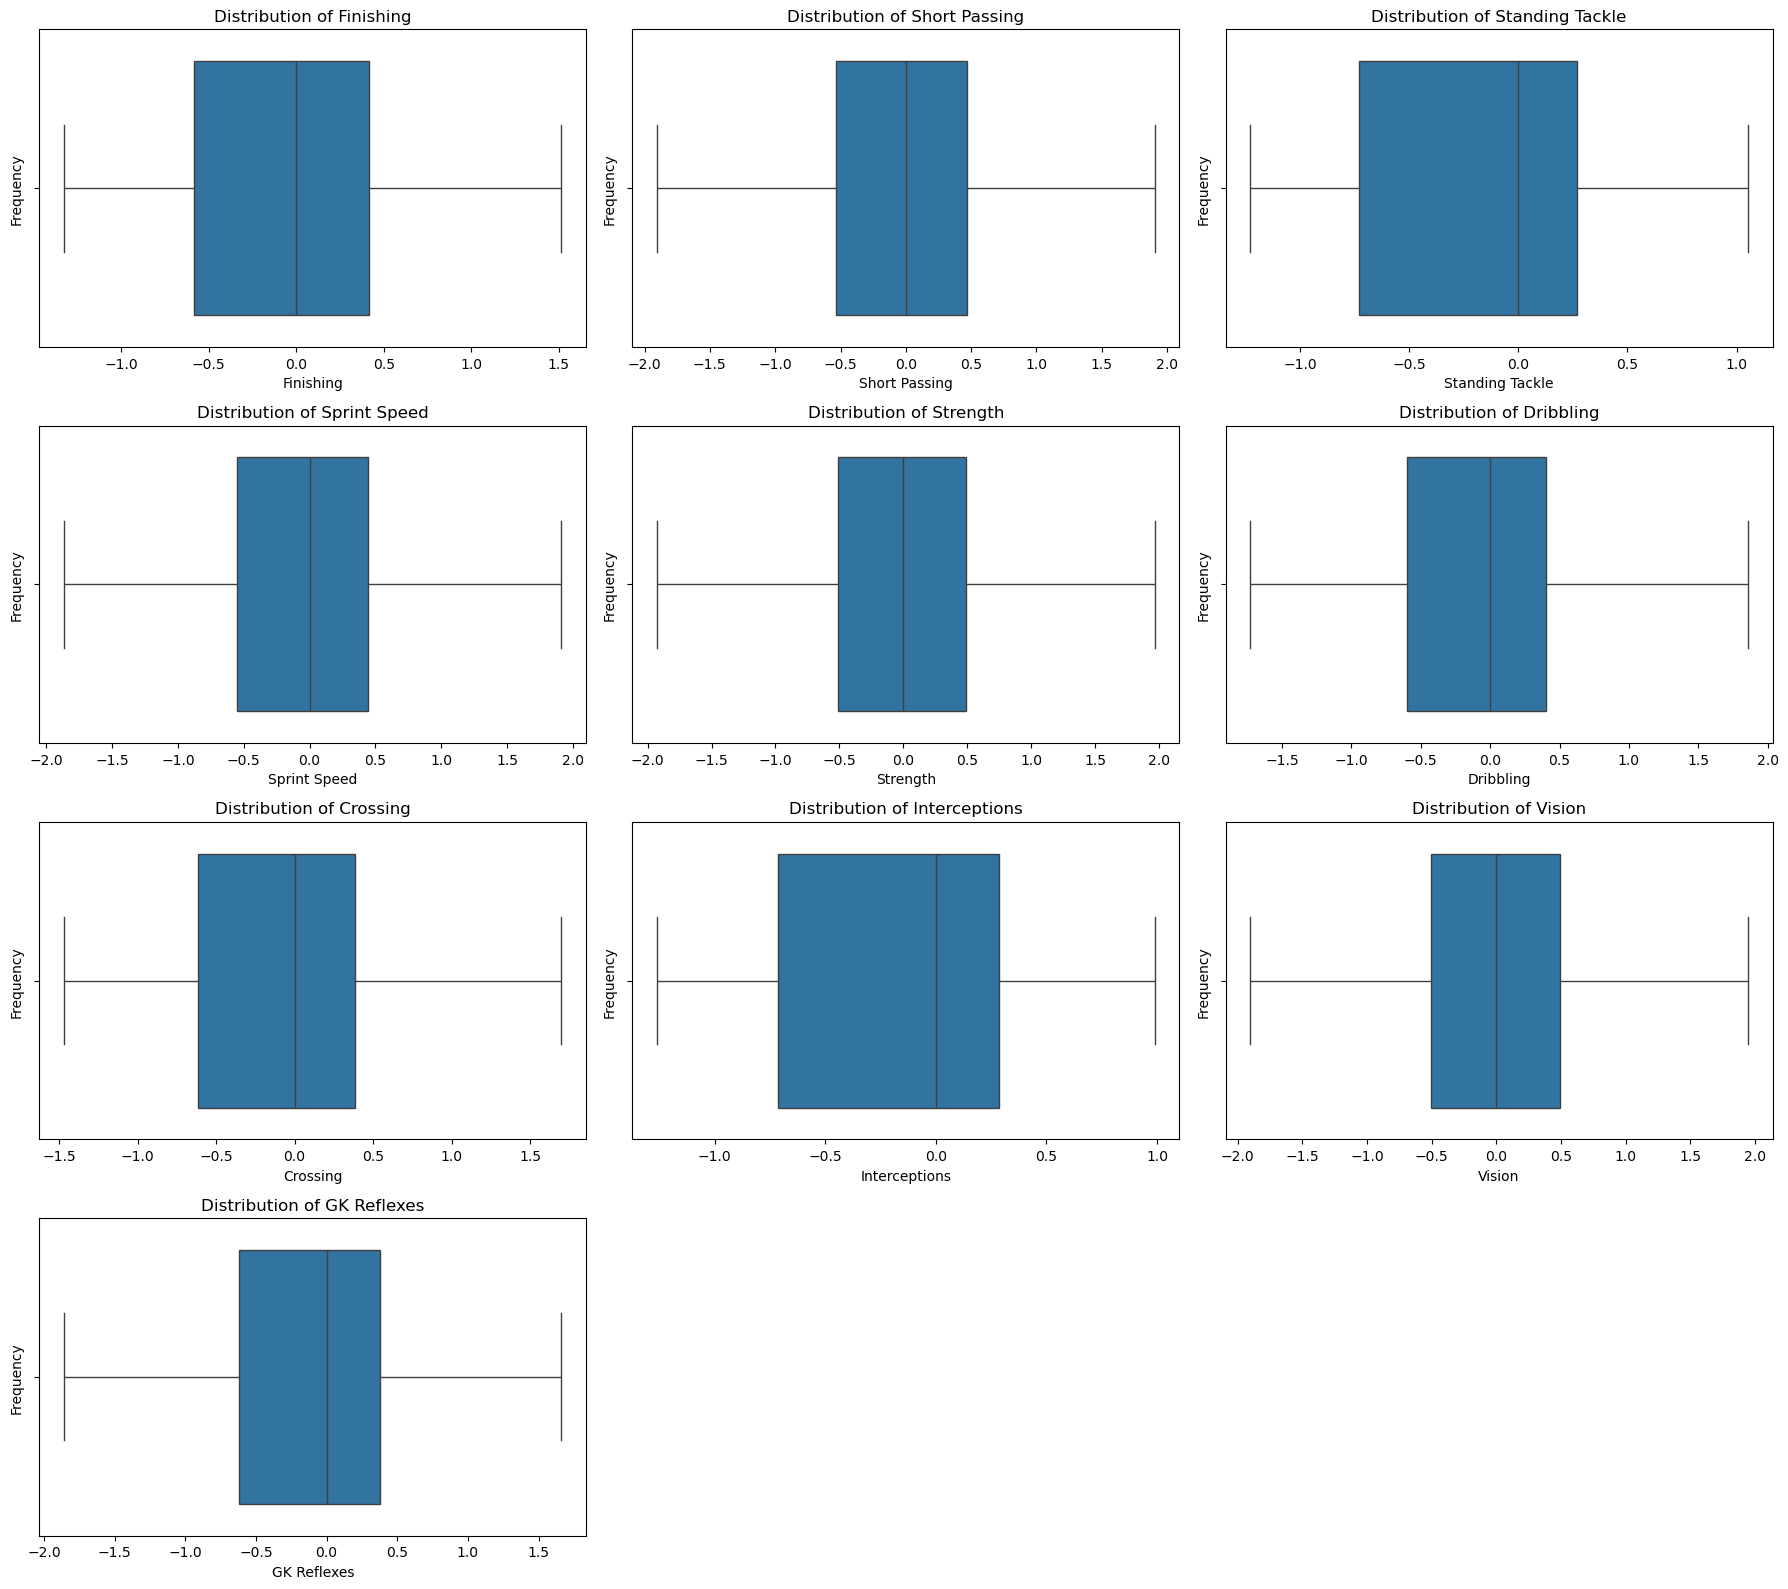

In [76]:
plot_feature_distributions(df_processed_without_outliers, features_for_clustering, flag='box')

### Plotting Features

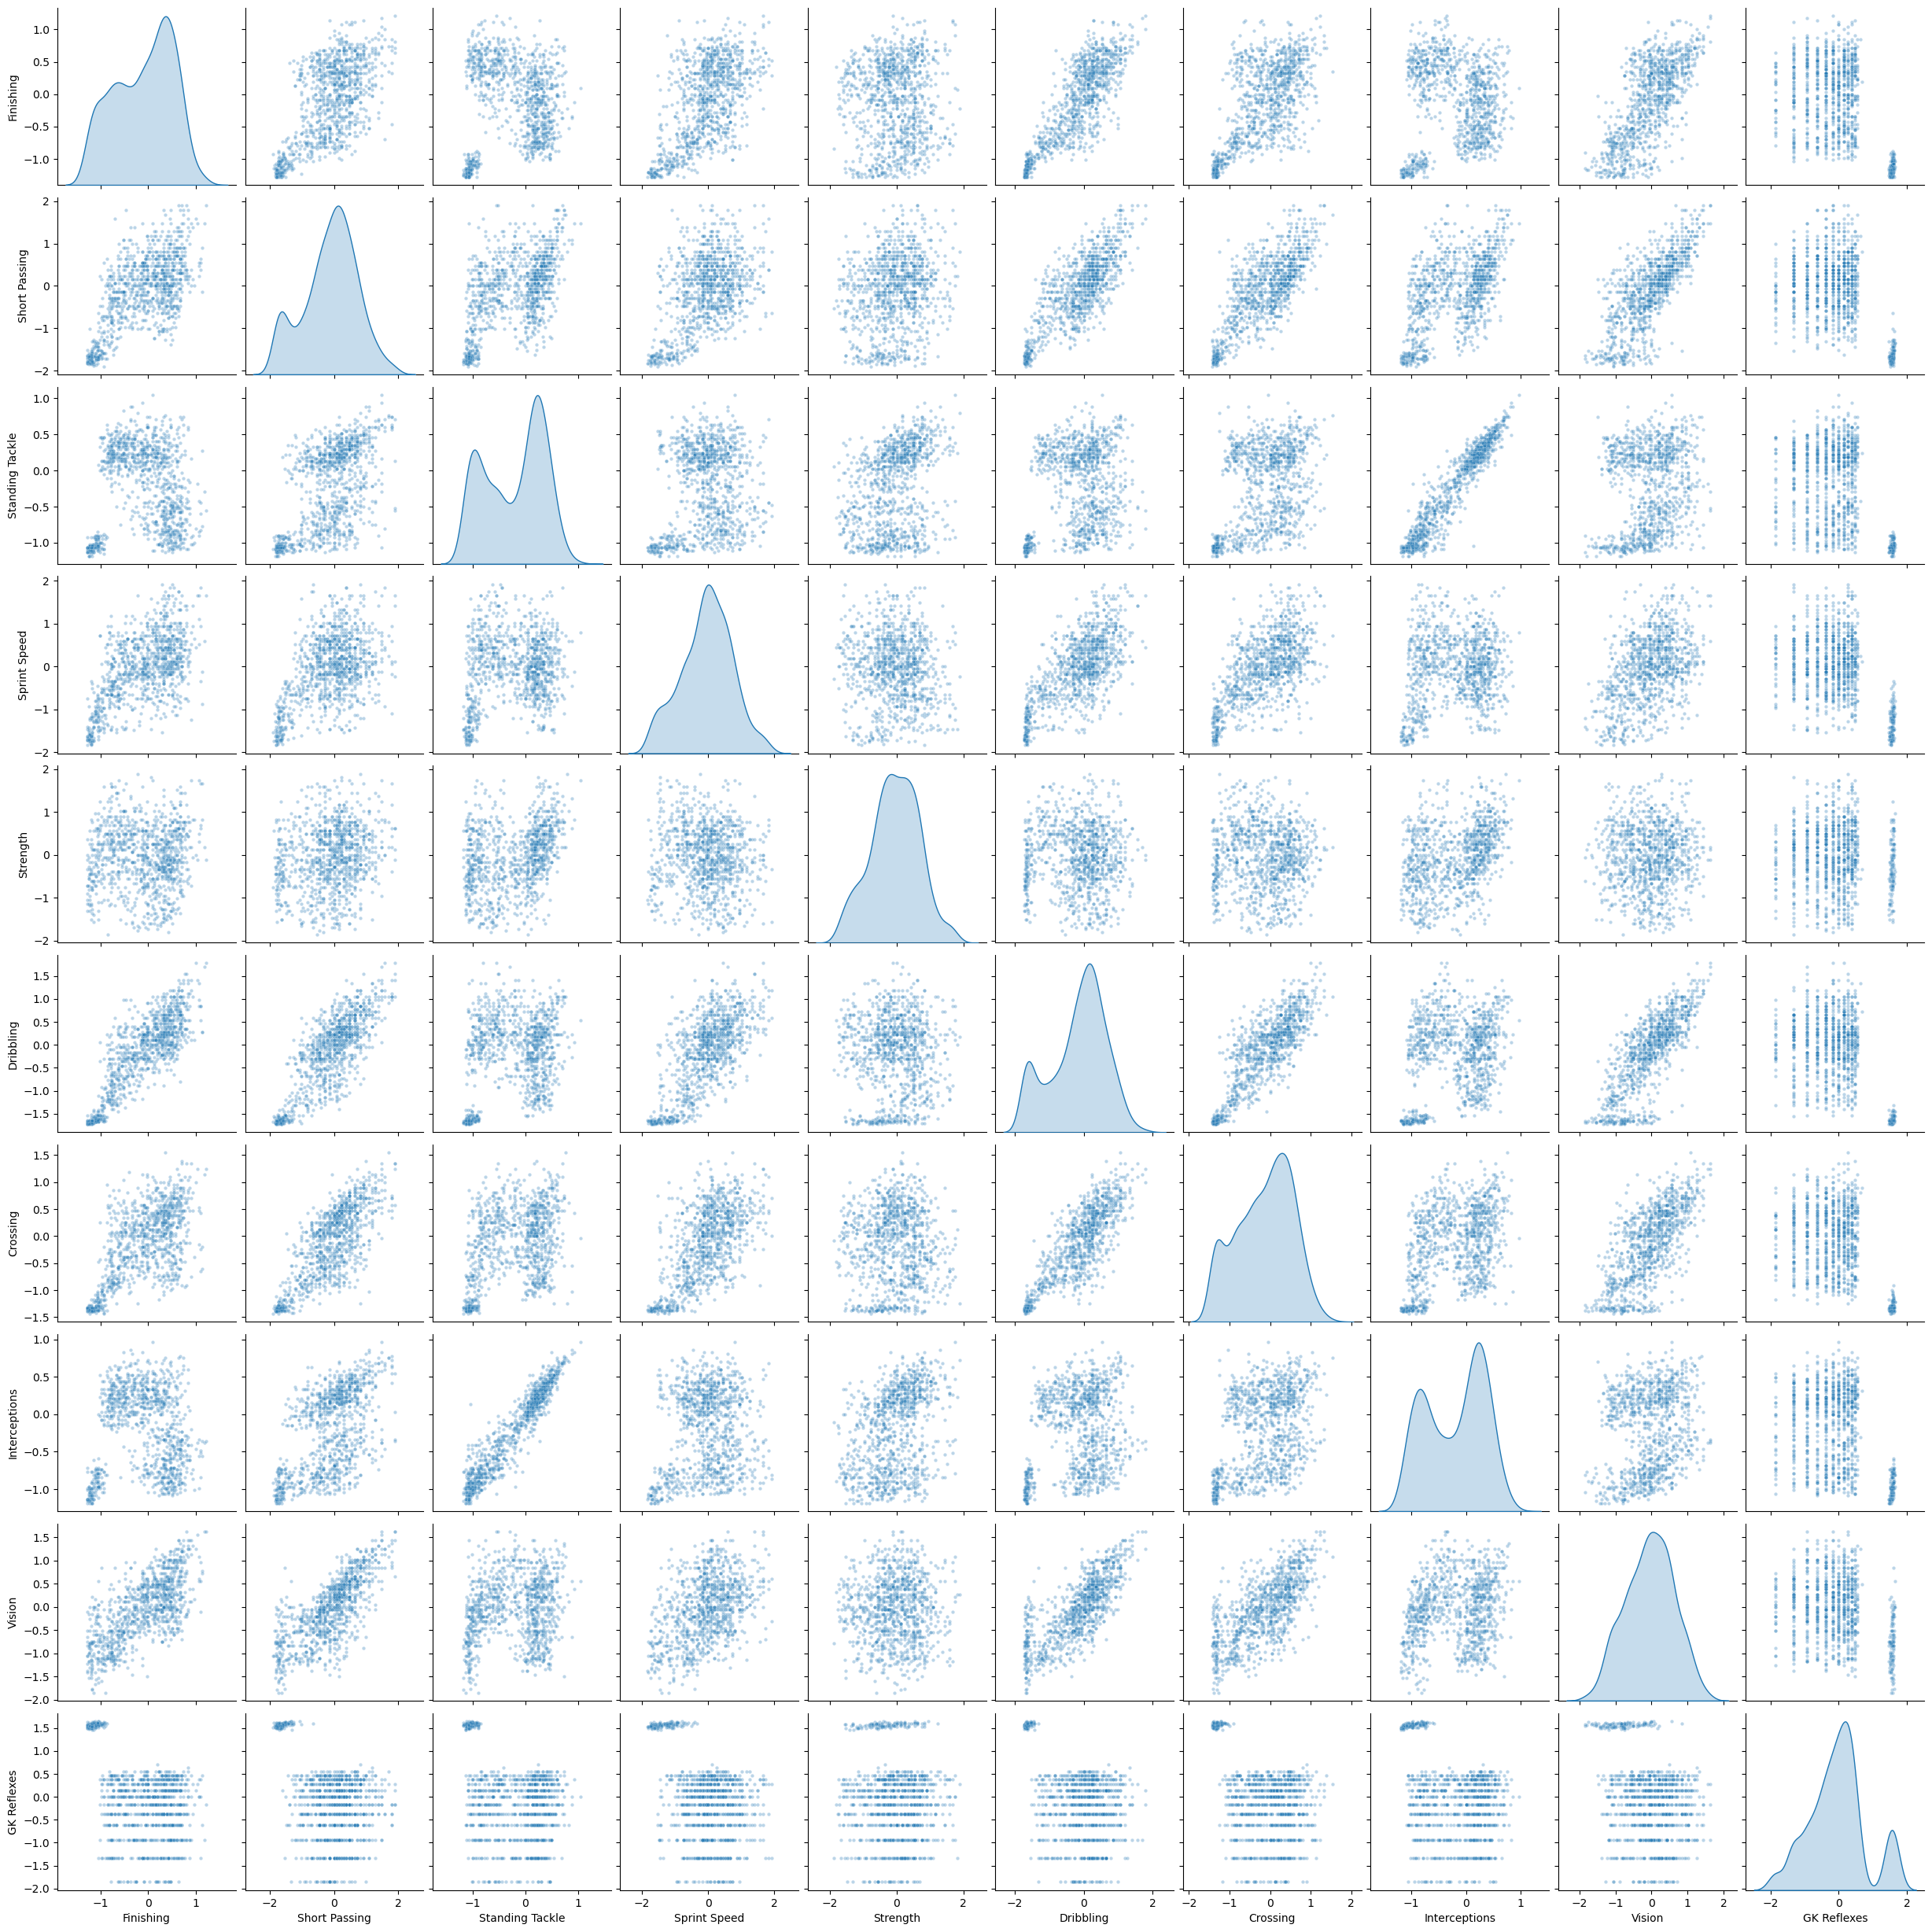

In [82]:
subset = ['Finishing', 'Standing Tackle', 'Sprint Speed', 'Short Passing']

sns.pairplot(df_processed_without_outliers[features_for_clustering].sample(1000), 
             diag_kind='kde', 
             plot_kws={'alpha': 0.3, 's': 10})
plt.show()

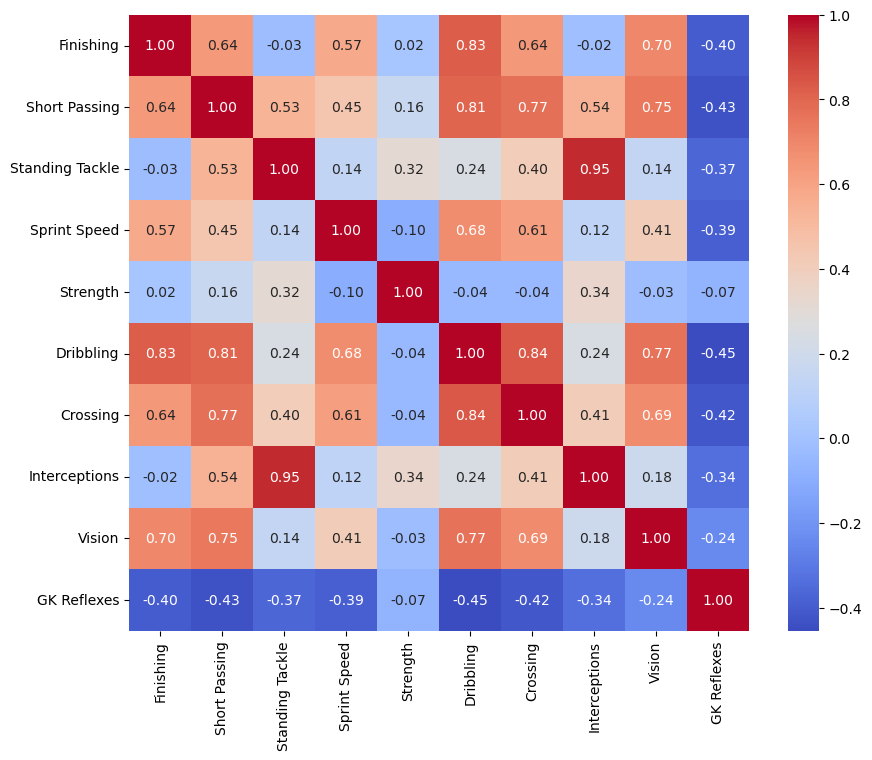

In [81]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

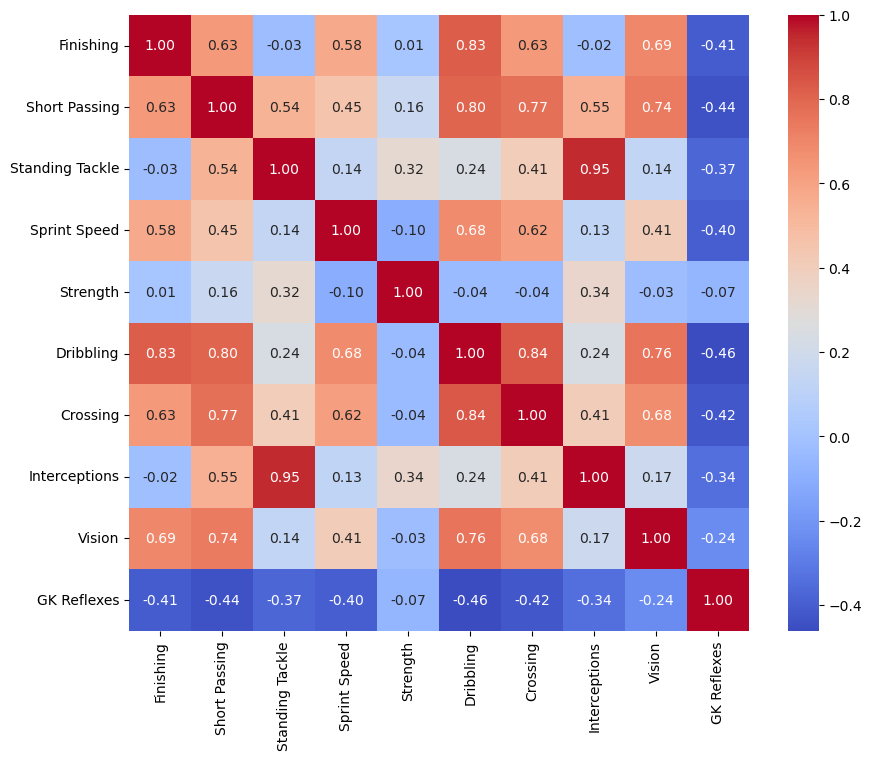

In [83]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_processed_without_outliers.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

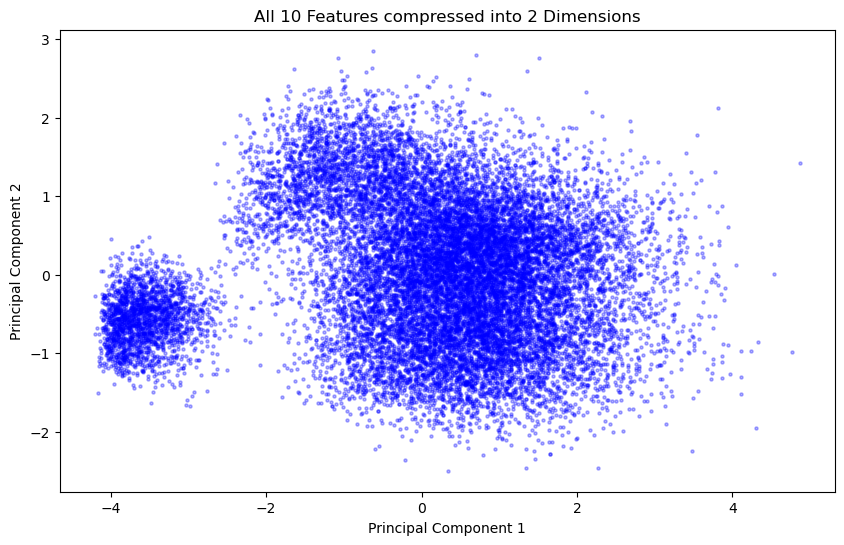

In [85]:

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_processed)

# Plot the result
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, c='blue')
plt.title('All 10 Features compressed into 2 Dimensions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [86]:
df_processed.to_csv('df_FIFA_cleaned_processed.csv', index=False)

## Cleaning Airplane Dataset

In [18]:
df_airplanes.head(10)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
5,6,16420,0,1,1,1,0,0,0,0,6942,0
6,7,84914,0,3,1,1,27482,25,0,0,6994,0
7,8,20856,0,1,1,1,5250,4,250,1,6938,1
8,9,443003,0,3,2,1,1753,43,3850,12,6948,1
9,10,104860,0,3,1,1,28426,28,1150,3,6931,1
